In [58]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [180]:
import os,sys
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import pandas as pd
import geopandas as gpd
import datetime
pd.options.display.max_columns = None
import xarray as xr
import seaborn as sns
sys.path.append('../../src/aorc/')
from manager_aorc import * 
from process_aorc import *

dir_watershed_boundary = '../../data/1_raw/watershed_boundaries/South_Fork/'
filename_watershed_boundary = 'South_Fork_05451210.shp'

# Load watershed boundary

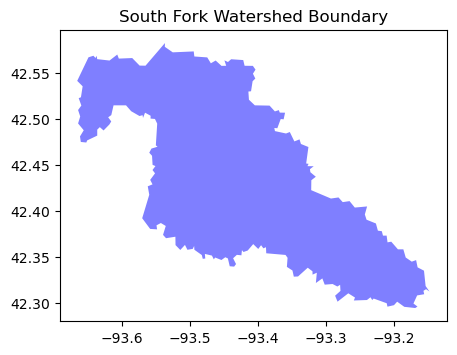

In [181]:
watershed_boundary = gpd.read_file(os.path.join(dir_watershed_boundary, filename_watershed_boundary))

fig, ax = plt.subplots(figsize=(5, 5))
watershed_boundary.plot(ax=ax, color='blue', alpha=0.5)
ax.set_title('South Fork Watershed Boundary')
plt.show()


# Download AORC data

In [191]:
to_download_aorc_data = False

if to_download_aorc_data:
    
    dir_output = '/Users/jgomezvelez/Downloads/aorc_data/'
    aorc_manager = FileManagerAORC(name = 'South_Fork_Watershed', dir_output = dir_output)

    start_year = 2007 #2007
    end_year = 2024

    aorc_manager._download(geometry=watershed_boundary, start_year=start_year, end_year=end_year)


# Process the AORC data

In [ ]:
filename_aorc = '/Users/jgomezvelez/Downloads/aorc_data/South_Fork_Watershed_aorc_2007-2024_42.582x-93.147_42.294x-93.666.nc'

ds_latlon = xr.open_dataset(filename_aorc)

ds_latlon

<xarray.Dataset> Size: 24GB
Dimensions:              (time: 157800, latitude: 37, longitude: 64)
Coordinates:
  * latitude             (latitude) float64 296B 42.29 42.3 ... 42.58 42.59
  * longitude            (longitude) float64 512B -93.67 -93.66 ... -93.14
  * time                 (time) datetime64[ns] 1MB 2007-01-01 ... 2024-12-31T...
Data variables:
    APCP_surface         (time, latitude, longitude) float64 3GB ...
    DLWRF_surface        (time, latitude, longitude) float64 3GB ...
    DSWRF_surface        (time, latitude, longitude) float64 3GB ...
    PRES_surface         (time, latitude, longitude) float64 3GB ...
    SPFH_2maboveground   (time, latitude, longitude) float64 3GB ...
    TMP_2maboveground    (time, latitude, longitude) float64 3GB ...
    UGRD_10maboveground  (time, latitude, longitude) float64 3GB ...
    VGRD_10maboveground  (time, latitude, longitude) float64 3GB ...

/opt/anaconda3/envs/env_datascience/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/env_datascience/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/env_datascience/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/env_datascience/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/env_datascience/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedo

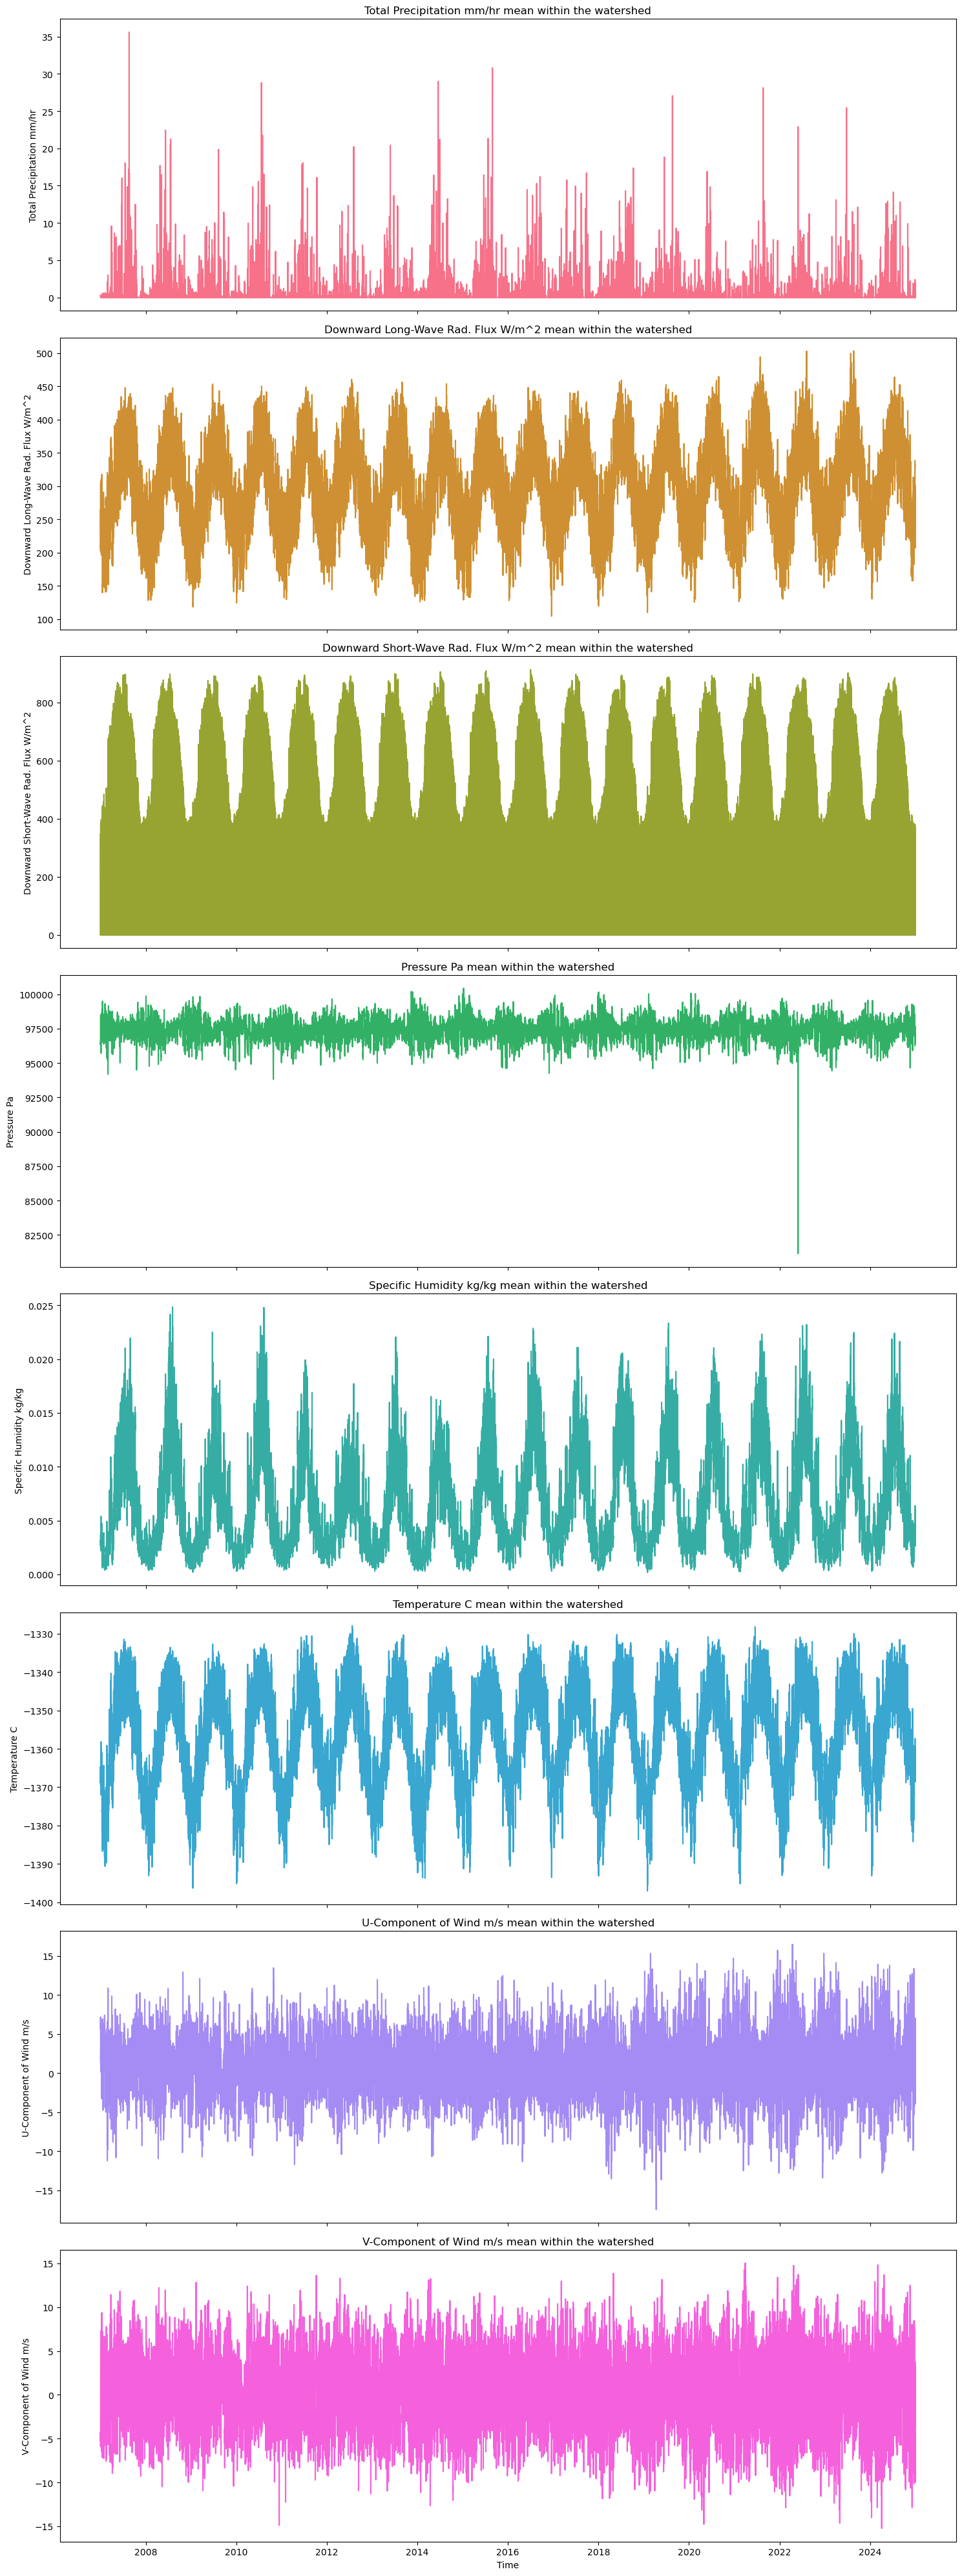

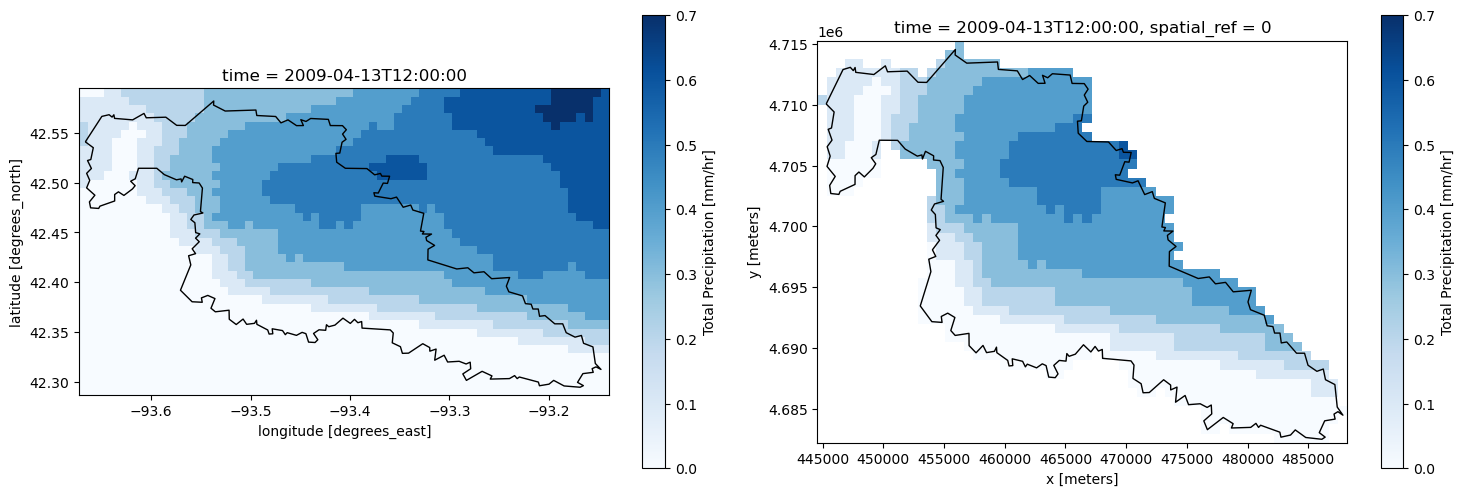

In [238]:
to_process_aorc_data = False

aorc_dir = os.path.dirname(filename_aorc)
aorc_file = os.path.basename(filename_aorc).split('.nc')[0] + '_UTM15N.nc'

if to_process_aorc_data:
    
    # Project and clip the AORC dataset to the watershed boundary
    crs_iowa = 'epsg:26915'
    ds_watershed_xy, watershed_boundary_xy = process_aorc_dataset(ds = ds_latlon, crs = crs_iowa, clip_geometry = watershed_boundary_latlon)

    encoding = {}
    for var in ds_watershed_xy.data_vars:
        encoding[var] = {
            'zlib': True,
            'complevel': 4,
            'shuffle': True,  # Helps compress NaN patterns
            'dtype': 'float32',  # Use float32 instead of float64
            '_FillValue': np.nan  # Explicitly set fill value
        }
    ds_watershed_xy.to_netcdf(os.path.join(aorc_dir, aorc_file), encoding=encoding)
    watershed_boundary_xy.to_file(os.path.join(aorc_dir, aorc_file.split('_aorc')[0] + '_UTM15N.shp'), driver='ESRI Shapefile')

else:
    ds_watershed_xy = xr.open_dataset(os.path.join(aorc_dir, aorc_file))
    watershed_boundary_xy = gpd.read_file(os.path.join(aorc_dir, aorc_file.split('_aorc')[0] + '_UTM15N.shp'))

# Aggregate within the watershed
df_agg_aorc = get_aggregated_time_series_aorc(ds_watershed_xy)
df_agg_aorc.to_pickle(os.path.join(aorc_dir, aorc_file.split('.nc')[0] + '_aggregated_time_series.pkl'))

fig, axes = plot_all_aorc_timeseries(df_agg_aorc)
fig.savefig(os.path.join(aorc_dir, aorc_file.split('.nc')[0] + '_aggregated_time_series.png'), dpi=500, bbox_inches='tight')

# Plot the comparison between the latitude and longitude and the x and y coordinates
fig, ax = plot_comparison_latlon_xy(
    ds_latlon=ds_latlon,
    ds_xy=ds_watershed_xy,
    var='APCP_surface',
    time_idx=20004,
    gdf_boundary_latlon=watershed_boundary_latlon,
    gdf_boundary_xy=watershed_boundary_xy,
)

fig.savefig(os.path.join(aorc_dir, aorc_file.split('.nc')[0] + '_projection_comparison.png'), dpi=500, bbox_inches='tight')